In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
MODEL_PATHS = [
    'qwen/qwen-2.5-7b-instruct',
    'qwen/qwen-2.5-32b-instruct',
    'qwen/qwen-2.5-72b-instruct',

    'qwen/qwen3-8b',
    'qwen/qwen3-14b',
    'qwen/qwen3-32b',
    'qwen/qwen3-235b-a22b',

    'google/gemma-2-9b-it',
    'google/gemma-2-27b-it',

    'google/gemma-3-4b-it',
    'google/gemma-3-12b-it',
    'google/gemma-3-27b-it',

    'openai/gpt-oss-20b',
    'openai/gpt-oss-120b',

    'mistralai/mistral-small-24b-instruct-2501',
    'mistralai/mistral-small-3.2-24b-instruct',
    'mistralai/mistral-small-2603',
    'mistralai/mistral-medium-3.1',
    'mistralai/mistral-large-2512',

    'z-ai/glm-4.5-air',
    'z-ai/glm-4.5',

    'moonshotai/kimi-k2.5',

    # 'allenai/olmo-3-7b-instruct',
    'allenai/olmo-3.1-32b-instruct',

    'openai/gpt-5.4-nano',
    'openai/gpt-5.4-mini',
    'openai/gpt-5.4',

    'anthropic/claude-sonnet-4.6',
    'anthropic/claude-opus-4.6',

    'google/gemini-2.5-flash-lite',
    'google/gemini-2.5-flash',
    'google/gemini-2.5-pro',
]

MODEL_PATH = MODEL_PATHS[0]
MODEL_NAME = MODEL_PATH.split('/')[-1]

os.makedirs(f'./figures/{MODEL_NAME}', exist_ok=True)

N_ITERS = 100

In [3]:
stim_path = '../stimuli/'

grammar_items = pd.read_csv(os.path.join(stim_path, 'MoralGrammar68.csv'))
economic_items = pd.read_csv(os.path.join(stim_path, 'MoralEconomic68.csv'))
human_ratings = pd.read_json(os.path.join(stim_path, 'moralgrammar68_human_ratings.json'), lines=True)

print(f'MoralGrammar68: {grammar_items.shape}')
print(f'MoralEconomic68: {economic_items.shape}')
print(f'Human ratings: {human_ratings.shape}')

MoralGrammar68: (68, 3)
MoralEconomic68: (68, 7)
Human ratings: (68, 7)


## Figure 1 — Cross-model correlations

                          model  r_grammar  p_grammar  r_economic   p_economic
           qwen-2.5-7b-instruct   0.479301   0.000035    0.727970 2.013613e-12
          qwen-2.5-32b-instruct   0.330127   0.005971    0.476269 4.037479e-05
          qwen-2.5-72b-instruct   0.386459   0.001133    0.566226 4.839455e-07
                       qwen3-8b   0.191908   0.116931    0.664849 6.285905e-10
                      qwen3-14b   0.118910   0.334141    0.762481 4.206824e-14
                      qwen3-32b   0.057415   0.641884    0.343653 4.114683e-03
                qwen3-235b-a22b   0.164227   0.180815    0.533775 2.767964e-06
                  gemma-2-9b-it   0.330376   0.005931    0.424923 1.222100e-03
                 gemma-2-27b-it   0.311054   0.009827    0.558161 7.595289e-07
                  gemma-3-4b-it   0.448344   0.000126    0.890591 1.813708e-20
                 gemma-3-12b-it   0.367266   0.002064    0.341905 4.321486e-03
                 gemma-3-27b-it   0.399289   0.00074

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


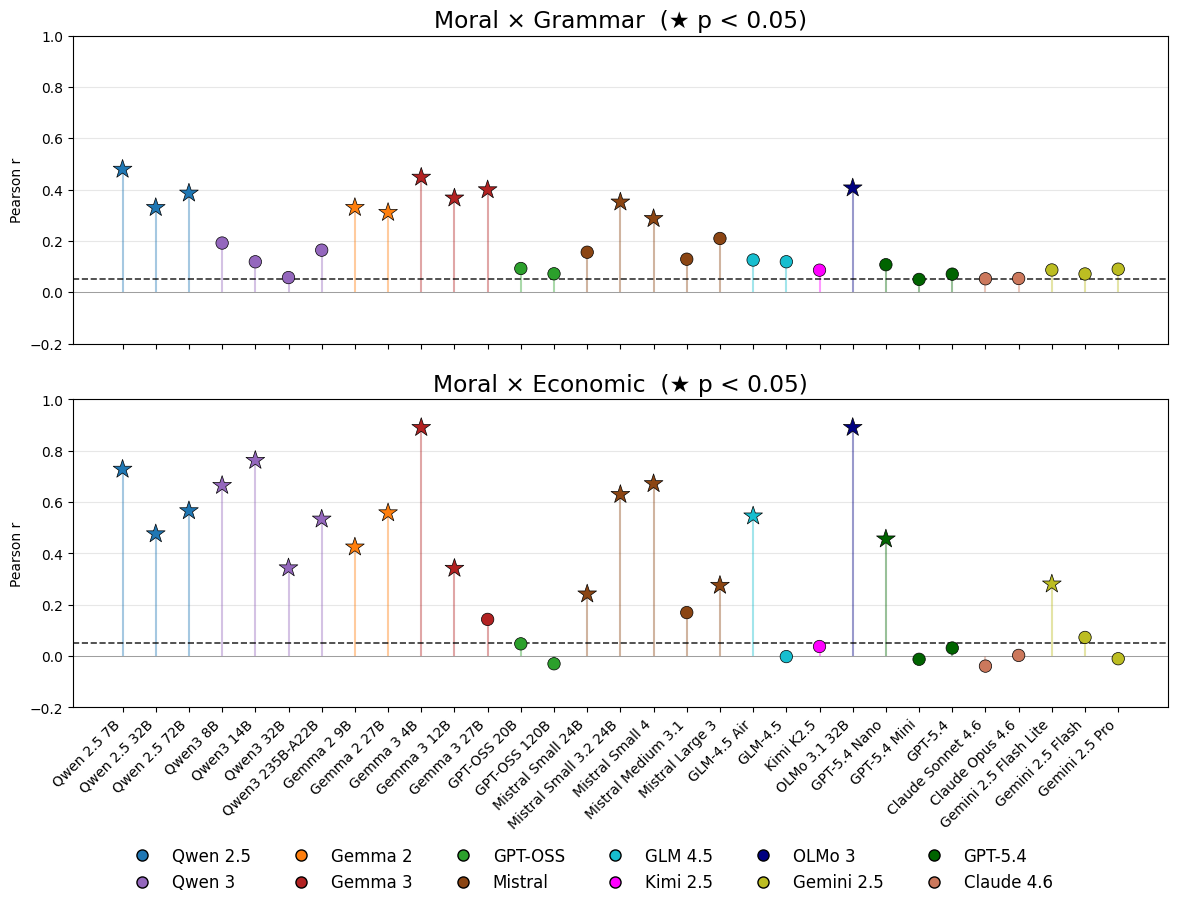

In [4]:
# ── Cross-model correlations ──
from scipy import stats as sp_stats
from matplotlib.lines import Line2D

ALPHA = 0.05

# ── Family palette (used here AND in the scaling plots below) ──
MODEL_FAMILY_COLORS = {
    'Qwen 2.5':     'tab:blue',
    'Qwen 3':       'tab:purple',
    'Gemma 2':      'tab:orange',
    'Gemma 3':      'firebrick',
    'GPT-OSS':      'tab:green',
    'Mistral':      'saddlebrown',
    'GLM 4.5':      'tab:cyan',
    'Kimi 2.5':     'magenta',
    'OLMo 3':       'navy',
    'Gemini 2.5':   'tab:olive',
    'GPT-5.4':      'darkgreen',
    'Claude 4.6':   '#cc785c',
}

def _family_of(model_name):
    if model_name.startswith('qwen-2.5'):  return 'Qwen 2.5'
    if model_name.startswith('qwen3'):     return 'Qwen 3'
    if model_name.startswith('gemma-2-'):  return 'Gemma 2'
    if model_name.startswith('gemma-3-'):  return 'Gemma 3'
    if model_name.startswith('gpt-oss'):   return 'GPT-OSS'
    if model_name.startswith('gpt-5'):     return 'GPT-5.4'
    if model_name.startswith('claude'):    return 'Claude 4.6'
    if model_name.startswith('mistral'):   return 'Mistral'
    if model_name.startswith('glm'):       return 'GLM 4.5'
    if model_name.startswith('kimi'):      return 'Kimi 2.5'
    if model_name.startswith('olmo'):      return 'OLMo 3'
    if model_name.startswith('gemini'):    return 'Gemini 2.5'
    return 'Other'

def _family_color(model_name):
    return MODEL_FAMILY_COLORS.get(_family_of(model_name), 'gray')

def _family_legend(fig, models_present, title=None,
                   loc='center right', bbox_to_anchor=(1.0, 0.5),
                   ncol=1, frameon=True):
    families_present = [f for f in MODEL_FAMILY_COLORS
                        if f in {_family_of(m) for m in models_present}]
    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=MODEL_FAMILY_COLORS[f],
                      markeredgecolor='black', markersize=8, label=f)
               for f in families_present]
    fig.legend(handles=handles, loc=loc, bbox_to_anchor=bbox_to_anchor,
               ncol=ncol, fontsize=12, title=title, frameon=frameon)

# ── Display labels (used for x-tick labels here AND scatter annotations below) ──
MODEL_DISPLAY_NAMES = {
    'qwen-2.5-7b-instruct':            'Qwen 2.5 7B',
    'qwen-2.5-32b-instruct':           'Qwen 2.5 32B',
    'qwen-2.5-72b-instruct':           'Qwen 2.5 72B',
    'qwen3-8b':                        'Qwen3 8B',
    'qwen3-14b':                       'Qwen3 14B',
    'qwen3-32b':                       'Qwen3 32B',
    'qwen3-235b-a22b':                 'Qwen3 235B-A22B',
    'gemma-2-9b-it':                   'Gemma 2 9B',
    'gemma-2-27b-it':                  'Gemma 2 27B',
    'gemma-3-4b-it':                   'Gemma 3 4B',
    'gemma-3-12b-it':                  'Gemma 3 12B',
    'gemma-3-27b-it':                  'Gemma 3 27B',
    'gpt-oss-20b':                     'GPT-OSS 20B',
    'gpt-oss-120b':                    'GPT-OSS 120B',
    'mistral-small-24b-instruct-2501': 'Mistral Small 24B',
    'mistral-small-3.2-24b-instruct':  'Mistral Small 3.2 24B',
    'mistral-small-2603':              'Mistral Small 4',
    'mistral-medium-3.1':              'Mistral Medium 3.1',
    'mistral-large-2512':              'Mistral Large 3',
    'glm-4.5-air':                     'GLM-4.5 Air',
    'glm-4.5':                         'GLM-4.5',
    'kimi-k2.5':                       'Kimi K2.5',
    'olmo-3-7b-instruct':              'OLMo 3 7B',
    'olmo-3.1-32b-instruct':           'OLMo 3.1 32B',
    'gemini-2.5-flash-lite':           'Gemini 2.5 Flash Lite',
    'gemini-2.5-flash':                'Gemini 2.5 Flash',
    'gemini-2.5-pro':                  'Gemini 2.5 Pro',
    'gpt-5.4-nano':                    'GPT-5.4 Nano',
    'gpt-5.4-mini':                    'GPT-5.4 Mini',
    'gpt-5.4':                         'GPT-5.4',
    'claude-sonnet-4.6':               'Claude Sonnet 4.6',
    'claude-opus-4.6':                 'Claude Opus 4.6',
}

def _short_name(model_name):
    return MODEL_DISPLAY_NAMES.get(model_name, model_name)


# ── Compute correlations + p-values per model ──
records = []
for mp in MODEL_PATHS:
    mn = mp.split('/')[-1]
    grammar_file = f'./data/{mn}/moralgrammar68_ratings.csv'
    economic_file = f'./data/{mn}/moraleconomic68_ratings.csv'

    r_gram, p_gram = np.nan, np.nan
    r_econ, p_econ = np.nan, np.nan

    if os.path.exists(grammar_file):
        gr = grammar_items.merge(pd.read_csv(grammar_file), on='item', how='left')
        gr = gr.dropna(subset=['morality_mean', 'grammar_mean'])
        if len(gr) >= 2:
            r_gram, p_gram = sp_stats.pearsonr(gr['morality_mean'], gr['grammar_mean'])

    if os.path.exists(economic_file):
        ec = economic_items.merge(pd.read_csv(economic_file), on='item', how='left')
        ec = ec.dropna(subset=['morality_mean', 'economic_mean'])
        if len(ec) >= 2:
            r_econ, p_econ = sp_stats.pearsonr(ec['morality_mean'], ec['economic_mean'])

    records.append({
        'model': mn,
        'r_grammar': r_gram, 'p_grammar': p_gram,
        'r_economic': r_econ, 'p_economic': p_econ,
    })

corr_df = pd.DataFrame(records)
print(corr_df.to_string(index=False))

# ── Human baselines (dashed reference lines) ──
r_human_grammar, _ = sp_stats.pearsonr(
    human_ratings['morality_rating'], human_ratings['syntax_rating'])

_mg_syn1 = grammar_items[grammar_items['syntax_level'] == 1].copy()
_mg_syn1['scenario_id'] = _mg_syn1.groupby('morality_level').cumcount() + 1
_mg_syn1 = _mg_syn1.merge(
    human_ratings[['item', 'morality_rating']], on='item', how='left')
_me_with_human = economic_items.merge(
    _mg_syn1[['morality_level', 'scenario_id', 'morality_rating']],
    left_on=['morality_level', 'id'],
    right_on=['morality_level', 'scenario_id'],
    how='left',
).dropna(subset=['morality_rating', 'price'])
r_human_economic, _ = sp_stats.pearsonr(
    _me_with_human['morality_rating'].values,
    np.log10(_me_with_human['price'].astype(float).values),
)
print(f'Human baseline r(moral, grammar) = {r_human_grammar:.3f}')
print(f'Human baseline r(moral, log10 price) = {r_human_economic:.3f} '
      f'(n={len(_me_with_human)})')

os.makedirs('./figures', exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
plt.rcParams.update({'font.size': 14})
x_pos = np.arange(len(corr_df))
fam_colors = np.array([_family_color(m) for m in corr_df['model']])

for ax, r_col, p_col, ylabel, r_human in [
    (axes[0], 'r_grammar',  'p_grammar',  'Pearson r',  r_human_grammar),
    (axes[1], 'r_economic', 'p_economic', 'Pearson r', r_human_economic),
]:
    rvals = corr_df[r_col].values
    pvals = corr_df[p_col].values
    has_data = ~np.isnan(rvals)
    sig = has_data & (pvals < ALPHA)
    nonsig = has_data & ~sig

    ax.vlines(x_pos[has_data], 0, rvals[has_data],
              colors=fam_colors[has_data], alpha=0.4)
    ax.scatter(x_pos[nonsig], rvals[nonsig], s=80, c=fam_colors[nonsig],
               edgecolors='black', linewidths=0.5, marker='o', zorder=3)
    ax.scatter(x_pos[sig], rvals[sig], s=200, c=fam_colors[sig],
               edgecolors='black', linewidths=0.5, marker='*', zorder=3)

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axhline(r_human, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_ylim(-0.2, 1)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([_short_name(m) for m in corr_df['model']],
                        rotation=45, ha='right')

axes[0].set_title(f'Moral × Grammar  (★ p < {ALPHA})')
axes[1].set_title(f'Moral × Economic  (★ p < {ALPHA})')

# ── Bottom-centered horizontal legend, no frame, no title ──
families_present = [f for f in MODEL_FAMILY_COLORS
                    if f in {_family_of(m) for m in corr_df['model']}]
handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=MODEL_FAMILY_COLORS[f],
                  markeredgecolor='black', markersize=8, label=f)
           for f in families_present]
fig.legend(handles=handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=-(-len(handles) // 2),
           fontsize=12, frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('./figures/cross_model_correlations.eps', format='eps', bbox_inches='tight')
plt.show()

## Figure S2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


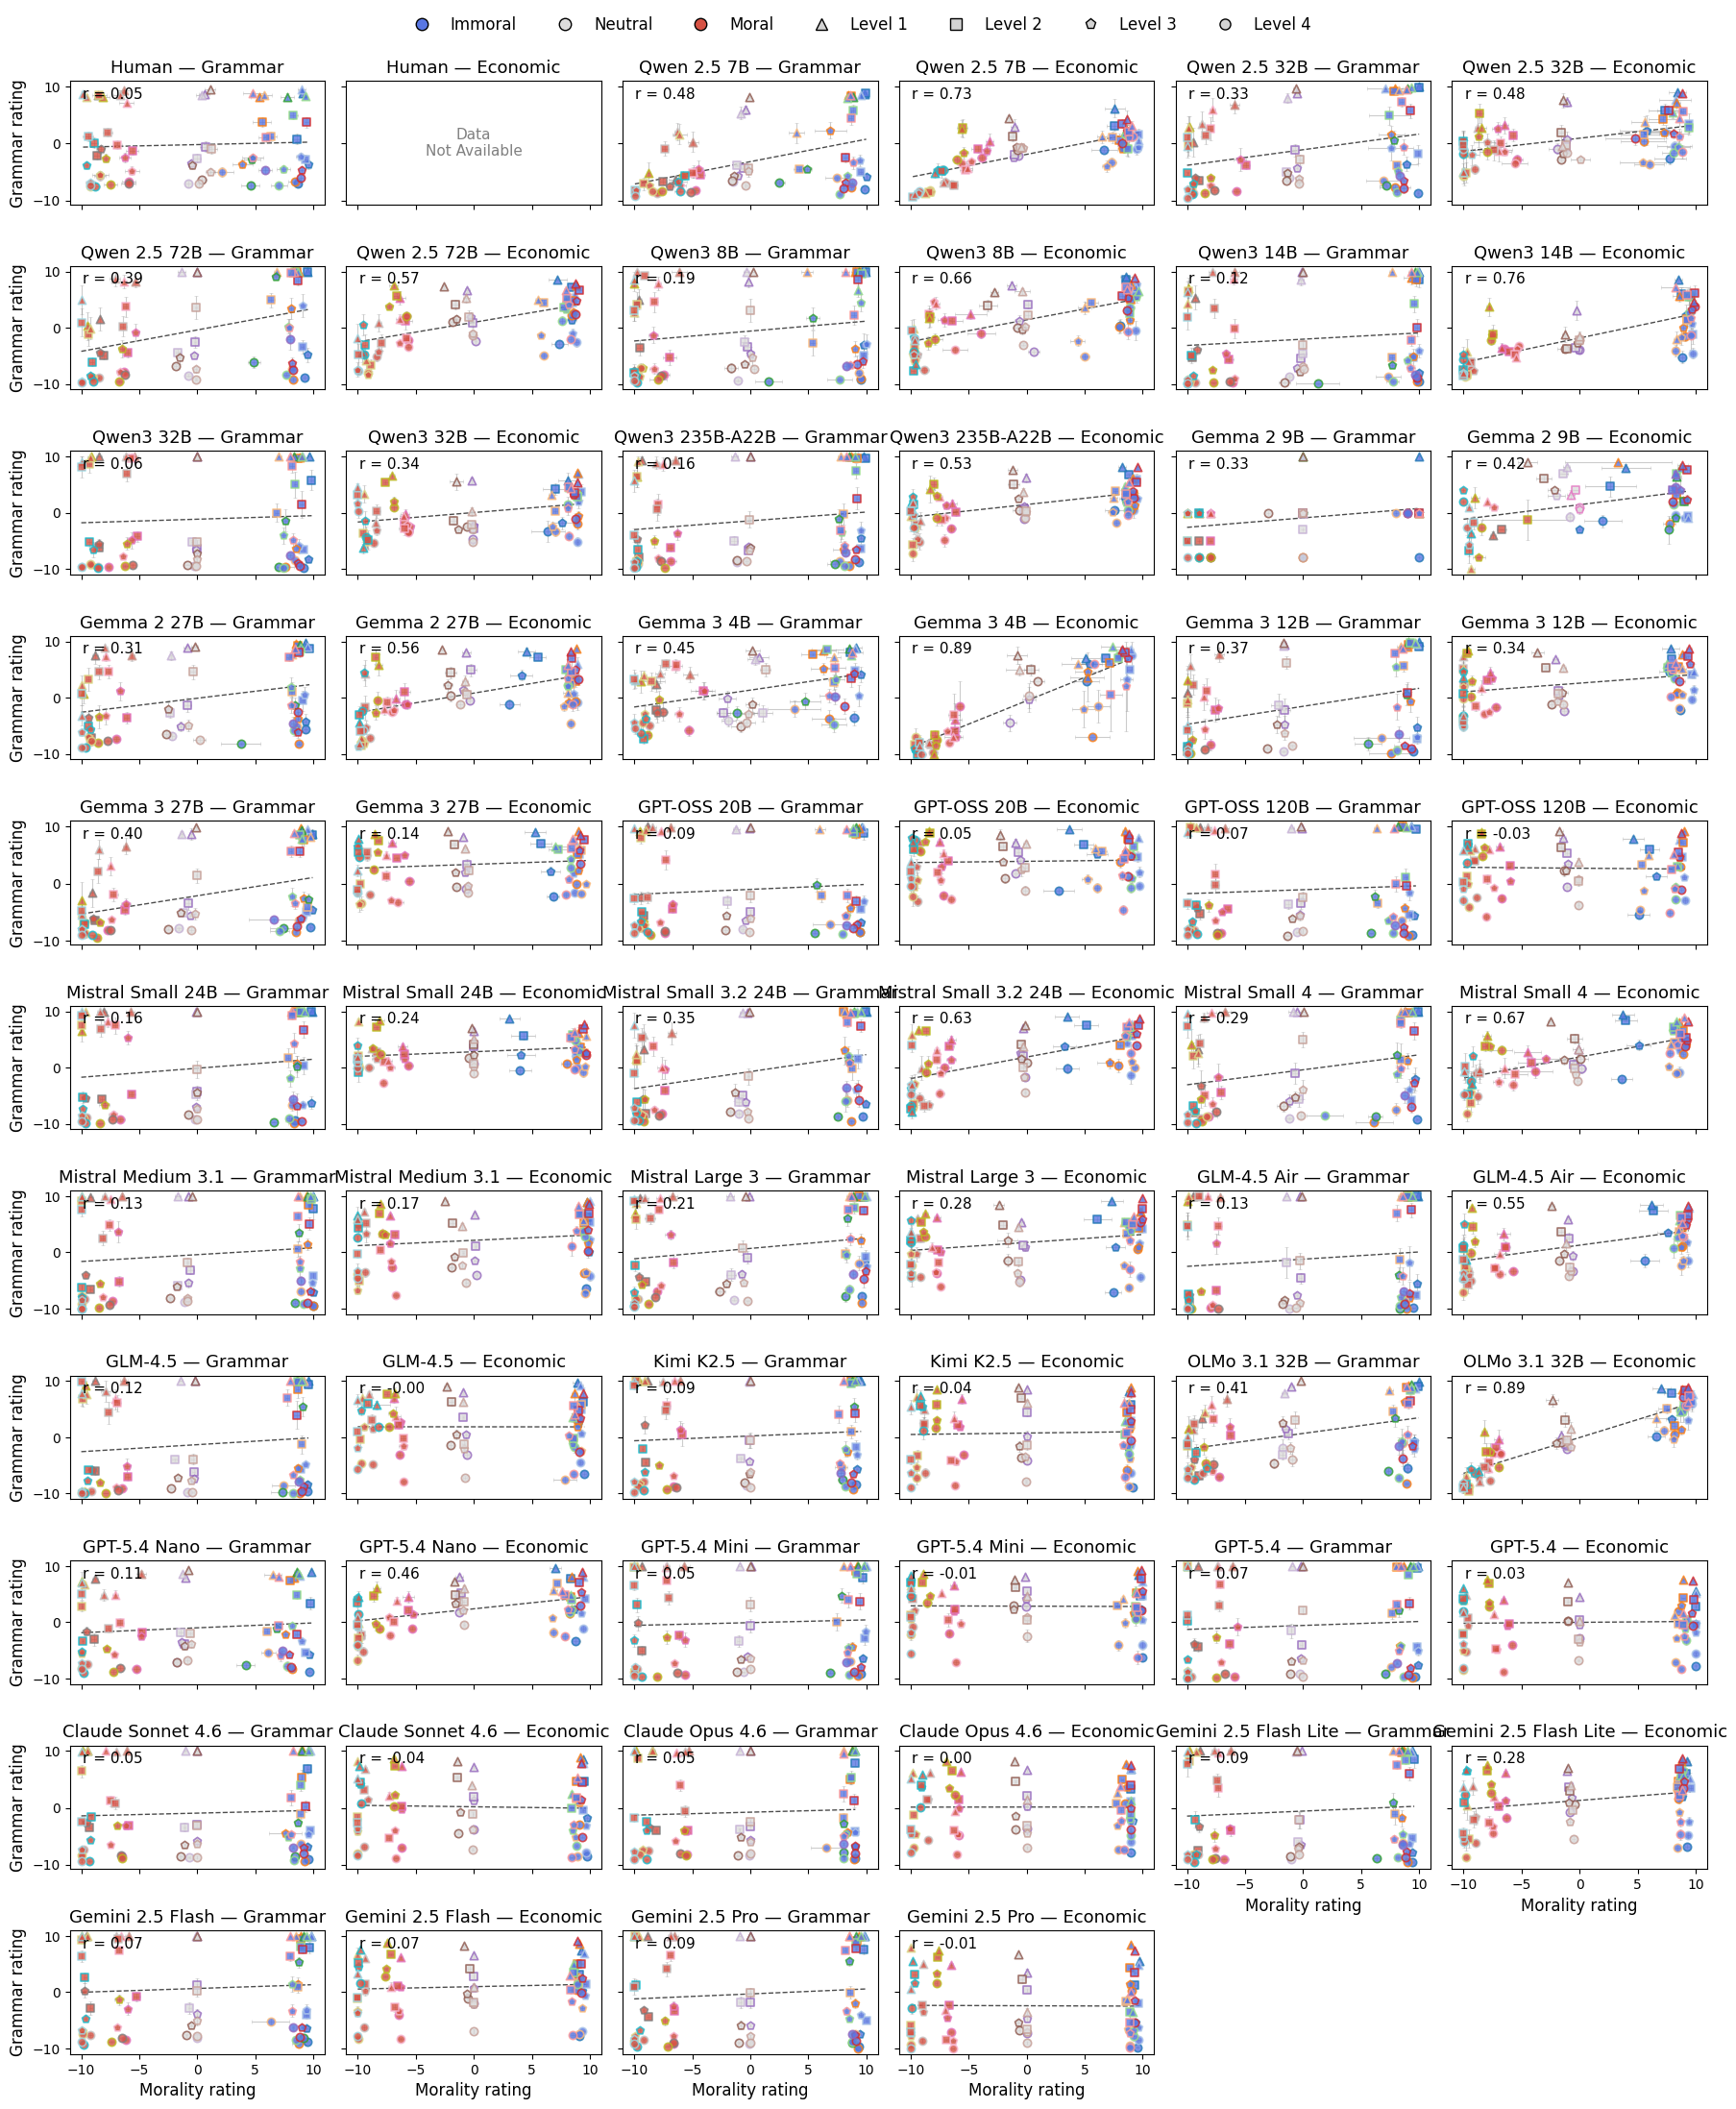

In [5]:
# ── Figure S2 — per-model scatter grid (N_ROWS rows × 6 cols) ──
from matplotlib import cm

FONT_SIZE_TITLE        = 13
FONT_SIZE_LABEL        = 12
FONT_SIZE_TICK         = 10
FONT_SIZE_TEXT         = 11
FONT_SIZE_LEGEND       = 12
FONT_SIZE_LEGEND_TITLE = 13

markers = ['^', 's', 'p', 'o']
morality_cmap   = cm.coolwarm
morality_colors = [morality_cmap(0.1), morality_cmap(0.5), morality_cmap(0.9)]
morality_labels = ['Immoral', 'Neutral', 'Moral']
edge_cmap       = cm.tab20

all_slots = ['Human'] + [mp.split('/')[-1] for mp in MODEL_PATHS]

N_PAIRS = 3
N_COLS  = N_PAIRS * 2
N_ROWS  = -(-(len(all_slots)) // N_PAIRS)

# ── Helpers ────────────────────────────────────────────────────────────────
GRAMMAR_RATE_COLS  = ['item', 'morality_mean', 'morality_SE', 'grammar_mean', 'grammar_SE']
ECONOMIC_RATE_COLS = ['item', 'morality_mean', 'morality_SE', 'economic_mean', 'economic_SE']

def _load_rate(path, keep_cols):
    df = pd.read_csv(path)
    return df[[c for c in keep_cols if c in df.columns]]

human_grammar = grammar_items.merge(human_ratings, on='item', how='left')
human_grammar = human_grammar.dropna(subset=['morality_rating', 'syntax_rating']).reset_index(drop=True)


def _scatter_panel(ax, df, x_col, y_col, x_se, y_se, level_col, edge_key):
    if len(df) == 0:
        return

    uniq = sorted(df[edge_key].unique())
    n = max(1, len(uniq) - 1)
    edge_lookup = {v: edge_cmap(i / n) for i, v in enumerate(uniq)}

    for i in range(len(df)):
        row = df.iloc[i]
        tier = int(row[level_col])
        m_idx = int(row['morality_level']) - 1
        x, y = row[x_col], row[y_col]
        xerr = row[x_se] if x_se in df.columns else 0
        yerr = row[y_se] if y_se in df.columns else 0
        ax.errorbar(x, y, xerr=xerr, yerr=yerr,
                    fmt='none', ecolor='gray', elinewidth=0.8,
                    capsize=1.5, capthick=0.4, alpha=0.4, zorder=1)
        ax.scatter(x, y,
                   c=[morality_colors[m_idx]],
                   marker=markers[(tier - 1) % len(markers)],
                   s=36, alpha=0.8,
                   edgecolors=[edge_lookup[row[edge_key]]],
                   linewidths=1.2, zorder=2)

    if len(df) >= 2:
        slope, intercept, _, _, _ = sp_stats.linregress(df[x_col], df[y_col])
        x_line = np.array([df[x_col].min(), df[x_col].max()])
        ax.plot(x_line, slope * x_line + intercept,
                'k--', linewidth=1.0, alpha=0.7, zorder=0)
        r = np.corrcoef(df[x_col], df[y_col])[0, 1]
        ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes,
                fontsize=FONT_SIZE_TEXT, verticalalignment='top')


def _missing(ax):
    ax.text(0.5, 0.5, 'Data\nNot Available', transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='gray')


fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, 2 * N_ROWS),
                         sharex='col', sharey='row')
plt.rcParams.update({'font.size': 11})

for slot_i, name in enumerate(all_slots[:N_ROWS * N_PAIRS]):
    row  = slot_i // N_PAIRS
    pair = slot_i %  N_PAIRS
    ax_g = axes[row, pair * 2]
    ax_e = axes[row, pair * 2 + 1]

    title_label = 'Human' if name == 'Human' else _short_name(name)

    # ── Grammar panel ──
    if name == 'Human':
        df_g = human_grammar.copy()
        df_g['_edge_id'] = df_g.index
        _scatter_panel(ax_g, df_g,
                       'morality_rating', 'syntax_rating',
                       'morality_SE', 'syntax_SE',
                       'syntax_level', '_edge_id')
    else:
        gpath = f'./data/{name}/moralgrammar68_ratings.csv'
        if os.path.exists(gpath):
            rate = _load_rate(gpath, GRAMMAR_RATE_COLS)
            df_g = (grammar_items.reset_index().rename(columns={'index': '_edge_id'})
                                  .merge(rate, on='item', how='left')
                                  .dropna(subset=['morality_mean', 'grammar_mean']))
            _scatter_panel(ax_g, df_g,
                           'morality_mean', 'grammar_mean',
                           'morality_SE', 'grammar_SE',
                           'syntax_level', '_edge_id')
        else:
            _missing(ax_g)

    ax_g.set_title(f'{title_label} — Grammar', fontsize=FONT_SIZE_TITLE)
    if pair == 0:
        ax_g.set_ylabel('Grammar rating', fontsize=FONT_SIZE_LABEL)
    if row == N_ROWS - 1:
        ax_g.set_xlabel('Morality rating', fontsize=FONT_SIZE_LABEL)
    ax_g.tick_params(axis='both', which='major', labelsize=FONT_SIZE_TICK)

    # ── Economic panel ──
    if name == 'Human':
        _missing(ax_e)
    else:
        epath = f'./data/{name}/moraleconomic68_ratings.csv'
        if os.path.exists(epath):
            rate = _load_rate(epath, ECONOMIC_RATE_COLS)
            df_e = (economic_items.merge(rate, on='item', how='left')
                                   .dropna(subset=['morality_mean', 'economic_mean']))
            _scatter_panel(ax_e, df_e,
                           'morality_mean', 'economic_mean',
                           'morality_SE', 'economic_SE',
                           'economic_level', 'id')
        else:
            _missing(ax_e)

    ax_e.set_title(f'{title_label} — Economic', fontsize=FONT_SIZE_TITLE)
    if row == N_ROWS - 1:
        ax_e.set_xlabel('Morality rating', fontsize=FONT_SIZE_LABEL)
    ax_e.tick_params(axis='both', which='major', labelsize=FONT_SIZE_TICK)

# ── Hide trailing empty slots and promote the row above to be the new bottom. ──
for slot_i in range(len(all_slots), N_ROWS * N_PAIRS):
    row  = slot_i // N_PAIRS
    pair = slot_i %  N_PAIRS
    for ax in (axes[row, pair * 2], axes[row, pair * 2 + 1]):
        ax.axis('off')
    if row > 0:
        for ax in (axes[row - 1, pair * 2], axes[row - 1, pair * 2 + 1]):
            ax.tick_params(axis='x', labelbottom=True)
            ax.set_xlabel('Morality rating', fontsize=FONT_SIZE_LABEL)

# ── Top horizontal legend, no frame. ──
legend_handles = (
    [Line2D([0], [0], marker='o', color='w',
            markerfacecolor=morality_colors[k],
            markeredgecolor='black', markersize=9, label=lab)
     for k, lab in enumerate(morality_labels)]
    + [Line2D([0], [0], marker=mk, color='w',
              markerfacecolor='lightgray',
              markeredgecolor='black', markersize=8, label=f'Level {k + 1}')
       for k, mk in enumerate(markers)]
)
fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 1.0), ncol=len(legend_handles),
           fontsize=FONT_SIZE_LEGEND, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.98])
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/figure_s1_per_model_scatter_8x6.eps',
            format='eps', bbox_inches='tight')
plt.savefig('./figures/figure_s1_per_model_scatter_8x6.png',
            format='png', dpi=200, bbox_inches='tight')
plt.show()

## Figure S2 — subset

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


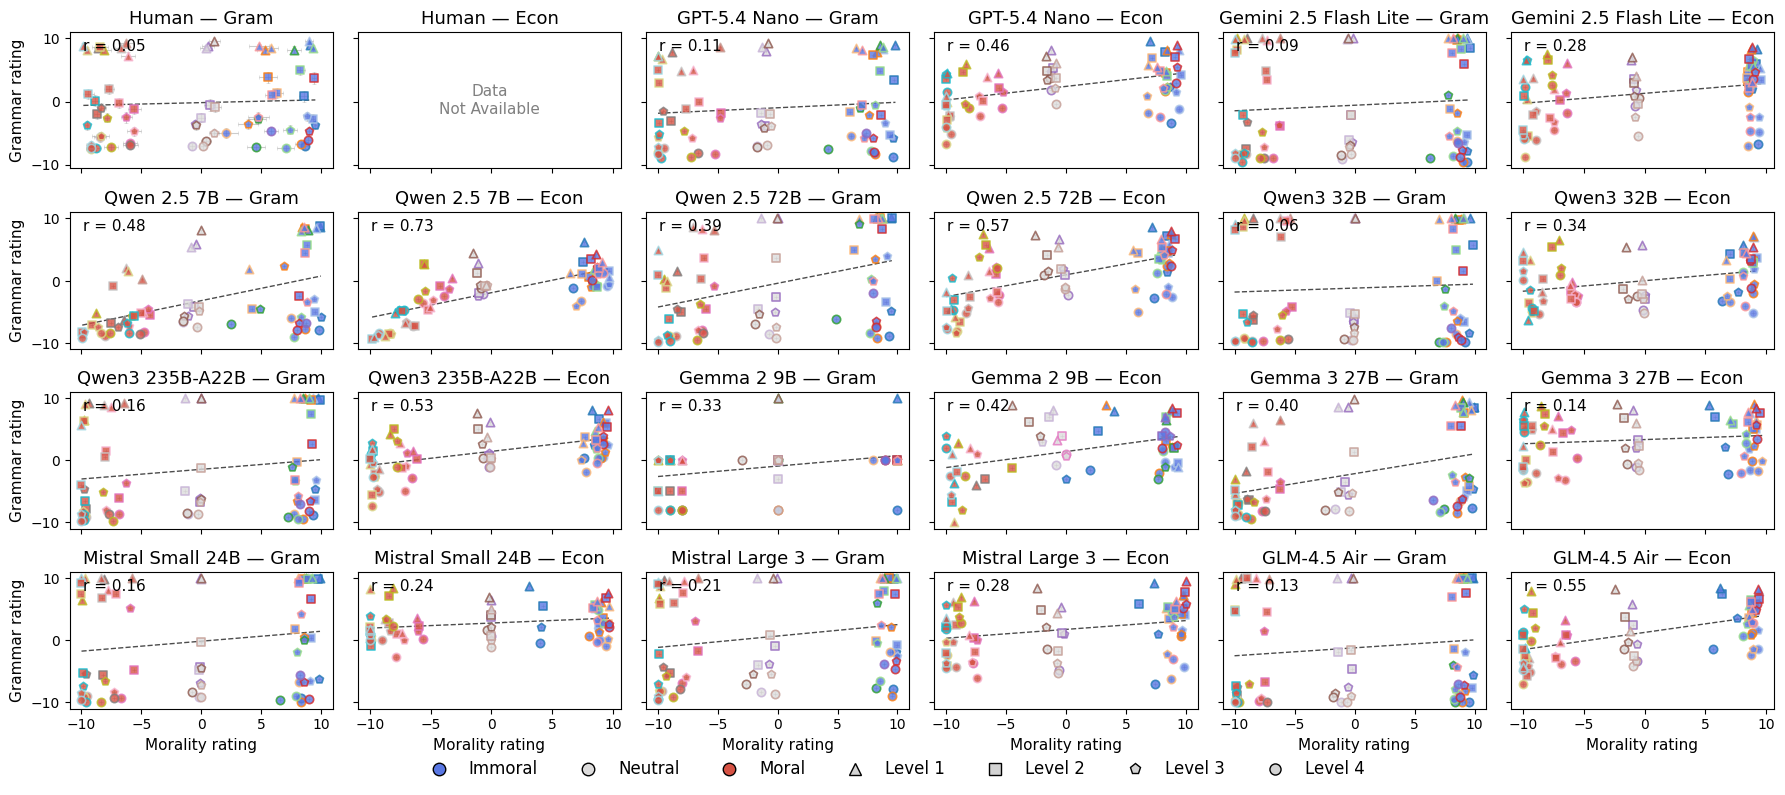

In [13]:
# ── Figure S2 (subset) — per-model scatter grid for Human + 11 models ──

SUBSET_MODEL_NAMES = [
    'gpt-5.4-nano',                      'gemini-2.5-flash-lite',             'qwen-2.5-7b-instruct',
    'qwen-2.5-72b-instruct',             'qwen3-32b',                         'qwen3-235b-a22b',
    'gemma-2-9b-it',                     'gemma-3-27b-it',                    'mistral-small-24b-instruct-2501',
    'mistral-large-2512',                'glm-4.5-air',
]

sub_slots = ['Human'] + SUBSET_MODEL_NAMES
sub_N_PAIRS = 3
sub_N_COLS  = sub_N_PAIRS * 2
sub_N_ROWS  = -(-(len(sub_slots)) // sub_N_PAIRS)

fig, axes = plt.subplots(sub_N_ROWS, sub_N_COLS,
                         figsize=(18, 2 * sub_N_ROWS),
                         sharex='col', sharey='row')
plt.rcParams.update({'font.size': 11})

for slot_i, name in enumerate(sub_slots):
    row  = slot_i // sub_N_PAIRS
    pair = slot_i %  sub_N_PAIRS
    ax_g = axes[row, pair * 2]
    ax_e = axes[row, pair * 2 + 1]

    title_label = 'Human' if name == 'Human' else _short_name(name)

    # ── Grammar panel ──
    if name == 'Human':
        df_g = human_grammar.copy()
        df_g['_edge_id'] = df_g.index
        _scatter_panel(ax_g, df_g,
                       'morality_rating', 'syntax_rating',
                       'morality_SE', 'syntax_SE',
                       'syntax_level', '_edge_id')
    else:
        gpath = f'./data/{name}/moralgrammar68_ratings.csv'
        if os.path.exists(gpath):
            rate = _load_rate(gpath, GRAMMAR_RATE_COLS)
            df_g = (grammar_items.reset_index().rename(columns={'index': '_edge_id'})
                                  .merge(rate, on='item', how='left')
                                  .dropna(subset=['morality_mean', 'grammar_mean']))
            _scatter_panel(ax_g, df_g,
                           'morality_mean', 'grammar_mean',
                           'morality_SE', 'grammar_SE',
                           'syntax_level', '_edge_id')
        else:
            _missing(ax_g)

    ax_g.set_title(f'{title_label} — Gram', fontsize=FONT_SIZE_TITLE)
    if pair == 0:
        ax_g.set_ylabel('Grammar rating', fontsize=FONT_SIZE_LABEL)
    if row == sub_N_ROWS - 1:
        ax_g.set_xlabel('Morality rating', fontsize=FONT_SIZE_LABEL)
    ax_g.tick_params(axis='both', which='major', labelsize=FONT_SIZE_TICK)

    # ── Economic panel ──
    if name == 'Human':
        _missing(ax_e)
    else:
        epath = f'./data/{name}/moraleconomic68_ratings.csv'
        if os.path.exists(epath):
            rate = _load_rate(epath, ECONOMIC_RATE_COLS)
            df_e = (economic_items.merge(rate, on='item', how='left')
                                   .dropna(subset=['morality_mean', 'economic_mean']))
            _scatter_panel(ax_e, df_e,
                           'morality_mean', 'economic_mean',
                           'morality_SE', 'economic_SE',
                           'economic_level', 'id')
        else:
            _missing(ax_e)

    ax_e.set_title(f'{title_label} — Econ', fontsize=FONT_SIZE_TITLE)
    if row == sub_N_ROWS - 1:
        ax_e.set_xlabel('Morality rating', fontsize=FONT_SIZE_LABEL)
    ax_e.tick_params(axis='both', which='major', labelsize=FONT_SIZE_TICK)

for slot_i in range(len(sub_slots), sub_N_ROWS * sub_N_PAIRS):
    row  = slot_i // sub_N_PAIRS
    pair = slot_i %  sub_N_PAIRS
    for ax in (axes[row, pair * 2], axes[row, pair * 2 + 1]):
        ax.axis('off')
    if row > 0:
        for ax in (axes[row - 1, pair * 2], axes[row - 1, pair * 2 + 1]):
            ax.tick_params(axis='x', labelbottom=True)
            ax.set_xlabel('Morality rating', fontsize=FONT_SIZE_LABEL)

legend_handles = (
    [Line2D([0], [0], marker='o', color='w',
            markerfacecolor=morality_colors[k],
            markeredgecolor='black', markersize=9, label=lab)
     for k, lab in enumerate(morality_labels)]
    + [Line2D([0], [0], marker=mk, color='w',
              markerfacecolor='lightgray',
              markeredgecolor='black', markersize=8, label=f'Level {k + 1}')
       for k, mk in enumerate(markers)]
)
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, 0.0), ncol=len(legend_handles),
           fontsize=FONT_SIZE_LEGEND, frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 1])
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/figure_s2_subset.eps',
            format='eps', bbox_inches='tight')
plt.savefig('./figures/figure_s2_subset.png',
            format='png', dpi=200, bbox_inches='tight')
plt.show()

## Figure S3

c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\admin\miniforge3\envs\Brain\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\admin\miniforge3\envs\Brain\

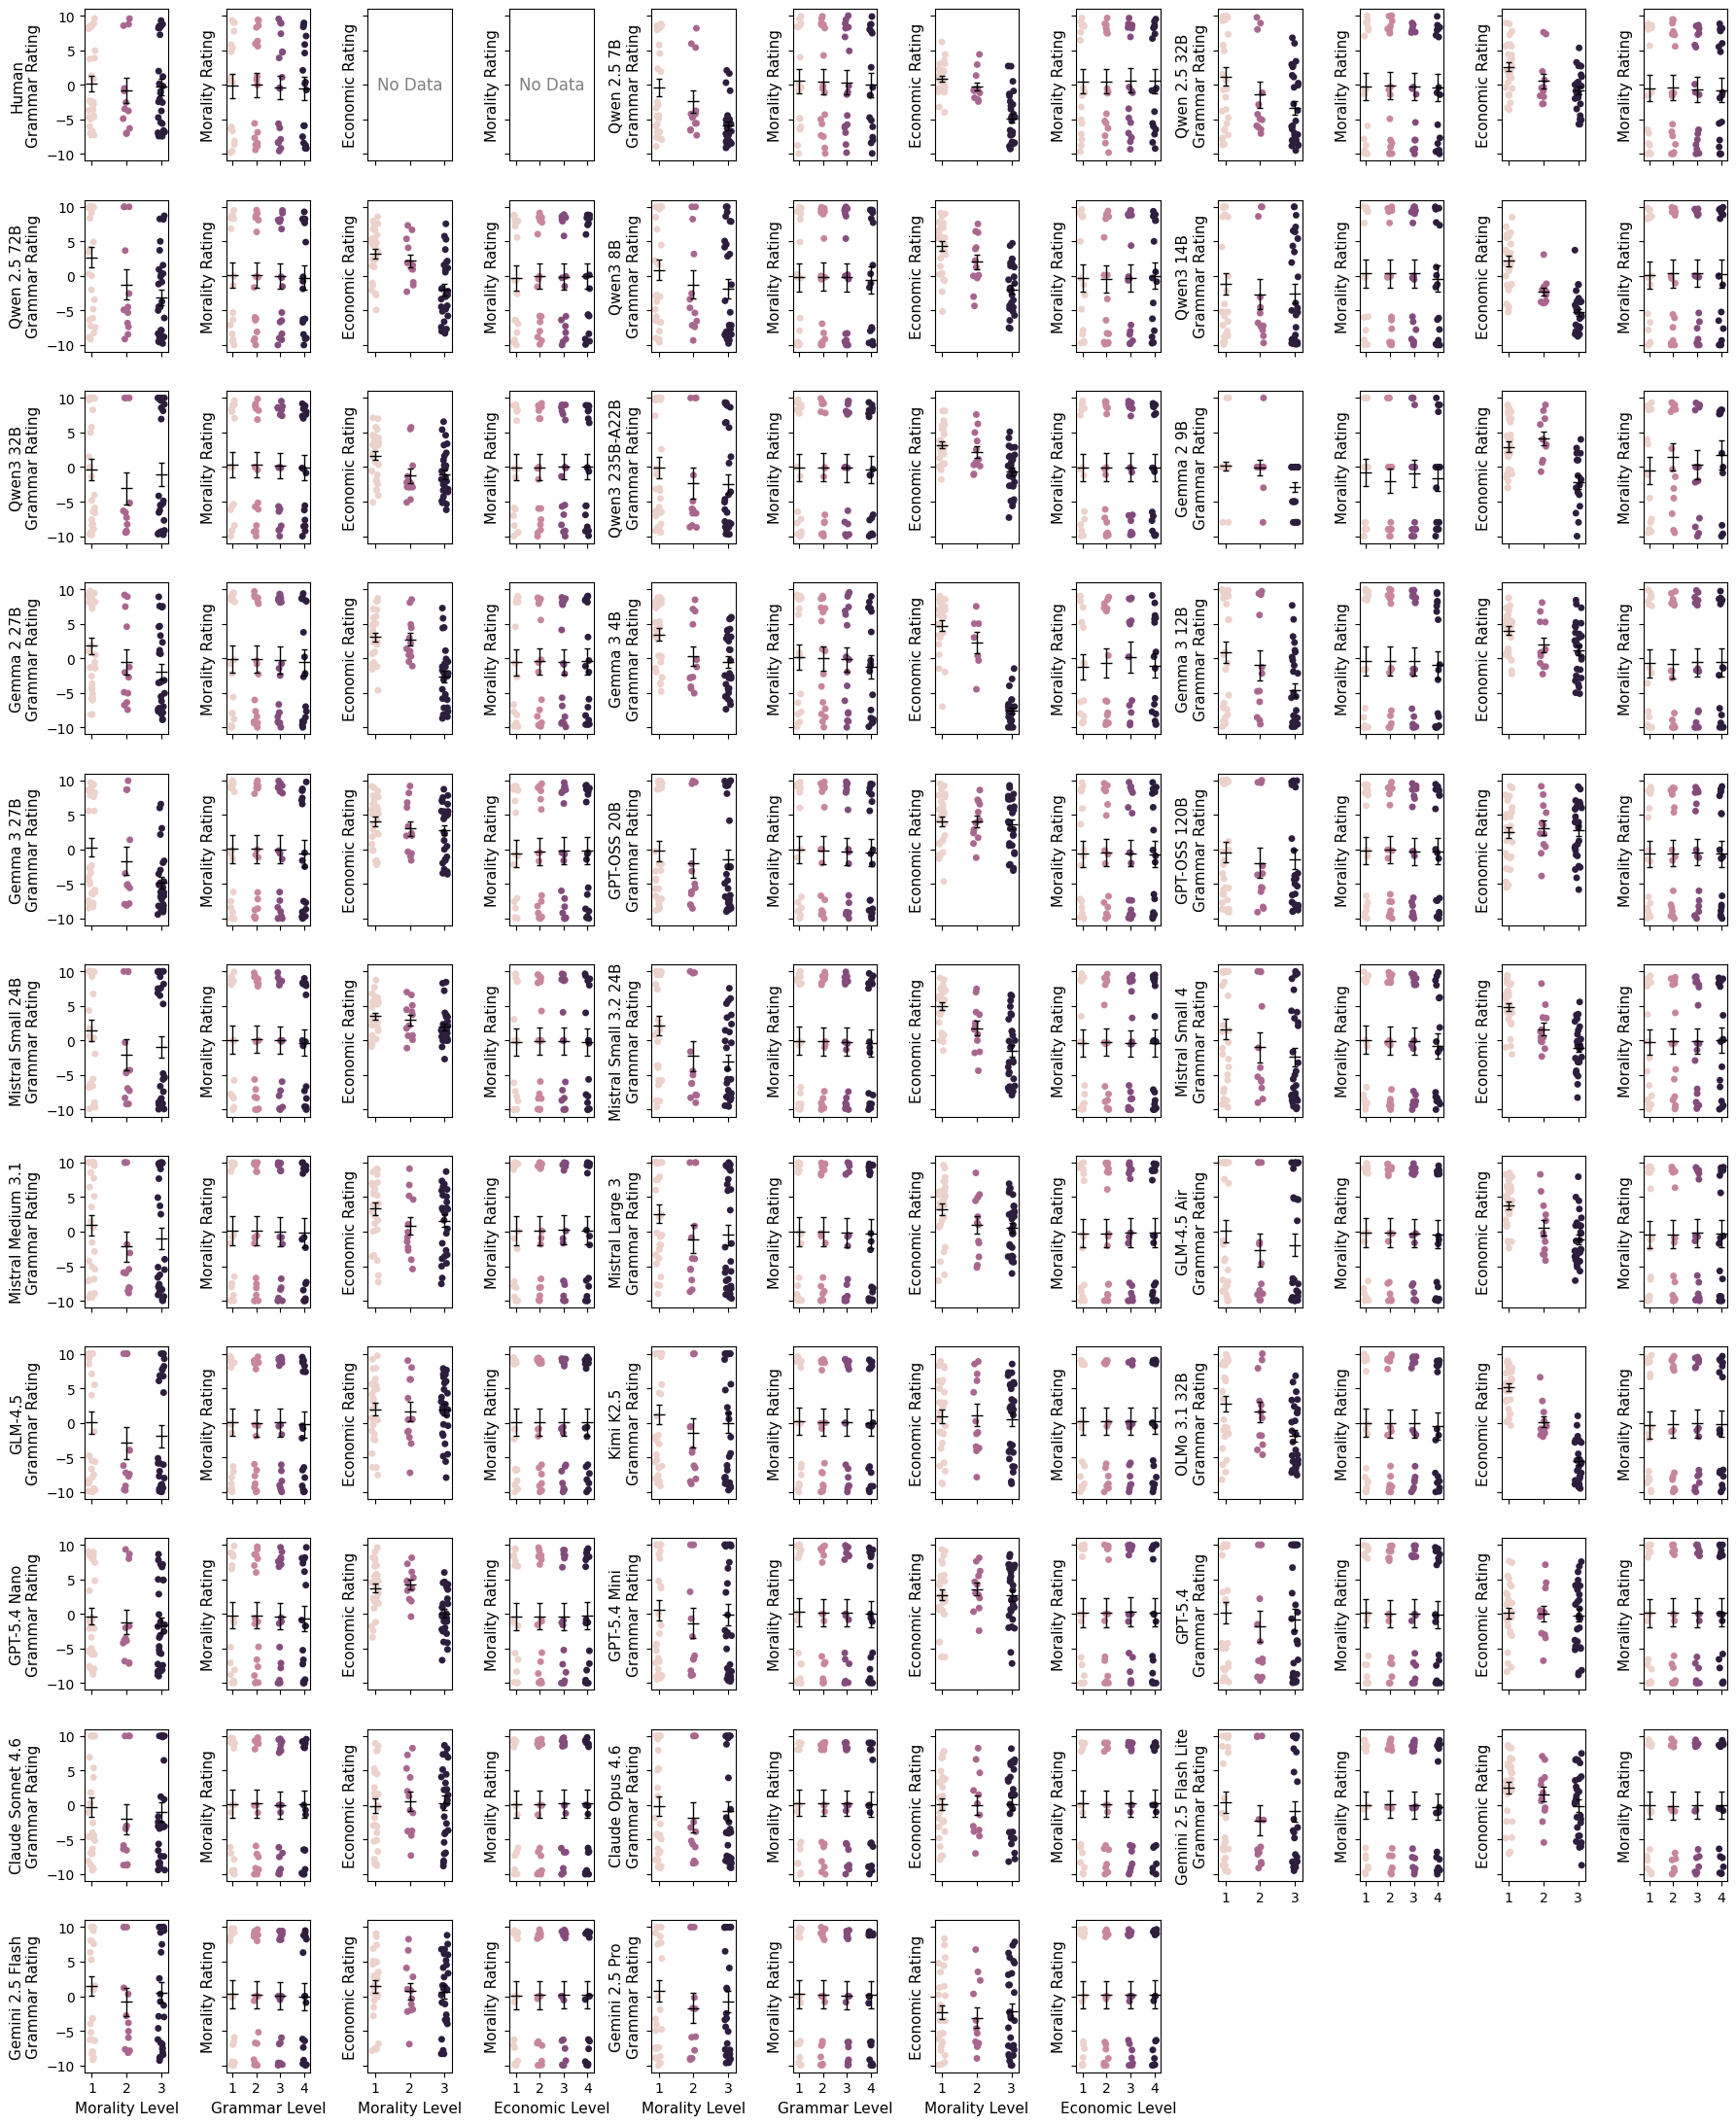

In [7]:
# ── Figure S3 — per-model stripplot grid (N_ROWS rows × 12 cols) ──
import seaborn as sns

FONT_SIZE_LABEL = 11
FONT_SIZE_TICK  = 10
FONT_SIZE_TITLE = 13

dot_palette = sns.cubehelix_palette(start=.5, rot=-.75)

GRAMMAR_RATE_COLS  = ['item', 'morality_mean', 'morality_SE', 'grammar_mean', 'grammar_SE']
ECONOMIC_RATE_COLS = ['item', 'morality_mean', 'morality_SE', 'economic_mean', 'economic_SE']

def _load_rate(path, keep_cols):
    df = pd.read_csv(path)
    return df[[c for c in keep_cols if c in df.columns]]

all_slots = ['Human'] + [mp.split('/')[-1] for mp in MODEL_PATHS]

MODELS_PER_ROW  = 3
COLS_PER_MODEL  = 4
N_COLS          = MODELS_PER_ROW * COLS_PER_MODEL
N_ROWS          = -(-(len(all_slots)) // MODELS_PER_ROW)

human_grammar = (grammar_items.merge(human_ratings, on='item', how='left')
                              .dropna(subset=['morality_rating', 'syntax_rating']))


def _plot_errorbars(ax, data, x_col, y_col):
    groups = sorted(data[x_col].dropna().unique())
    for i, g in enumerate(groups):
        gd = data[data[x_col] == g]
        if len(gd) == 0:
            continue
        ax.errorbar(x=i, y=gd[y_col].mean(), yerr=gd[y_col].sem(),
                    fmt='_', color='black', elinewidth=1, 
                    capsize=2.5, markersize=8, zorder=10,
                    )


def _strip(ax, df, x_col, y_col):
    if df is None or len(df) == 0:
        ax.text(0.5, 0.5, 'Data\nNot Available', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray')
        return
    sns.stripplot(x=x_col, y=y_col, hue=x_col,
                  data=df, size=5, jitter=True, ax=ax, legend=False,
                  zorder=1, 
                  # palette=dot_palette
                  )
    _plot_errorbars(ax, df, x_col, y_col)


def _no_data(ax):
    ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes,
            ha='center', va='center', fontsize=12, color='gray')


fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(18, 2 * N_ROWS),
                         sharex='col', sharey=True)
plt.rcParams.update({'font.size': 11})

COL_X_LABELS = ['Morality Level', 'Grammar Level',
                'Morality Level', 'Economic Level'] * MODELS_PER_ROW

for slot_i, name in enumerate(all_slots[:N_ROWS * MODELS_PER_ROW]):
    row  = slot_i // MODELS_PER_ROW
    col  = slot_i %  MODELS_PER_ROW
    base = col * COLS_PER_MODEL

    if name == 'Human':
        df_g = human_grammar
        df_e = None
        title_label = 'Human'
    else:
        title_label = _short_name(name)
        gpath = f'./data/{name}/moralgrammar68_ratings.csv'
        epath = f'./data/{name}/moraleconomic68_ratings.csv'
        df_g = (grammar_items.merge(_load_rate(gpath, GRAMMAR_RATE_COLS),
                                    on='item', how='left')
                              .dropna(subset=['morality_mean', 'grammar_mean'])
                if os.path.exists(gpath) else None)
        df_e = (economic_items.merge(_load_rate(epath, ECONOMIC_RATE_COLS),
                                     on='item', how='left')
                               .dropna(subset=['morality_mean', 'economic_mean'])
                if os.path.exists(epath) else None)

    # ── col 0: Grammar rating vs morality_level ──
    ax = axes[row, base + 0]
    if name == 'Human':
        _strip(ax, df_g, 'morality_level', 'syntax_rating')
    else:
        _strip(ax, df_g, 'morality_level', 'grammar_mean')
    ax.set_ylabel(f'{title_label}\nGrammar Rating', fontsize=FONT_SIZE_LABEL)

    # ── col 1: Morality rating vs syntax_level ──
    ax = axes[row, base + 1]
    if name == 'Human':
        _strip(ax, df_g, 'syntax_level', 'morality_rating')
    else:
        _strip(ax, df_g, 'syntax_level', 'morality_mean')
    ax.set_ylabel('Morality Rating', fontsize=FONT_SIZE_LABEL)

    # ── col 2: Economic rating vs morality_level ──
    ax = axes[row, base + 2]
    if name == 'Human':
        _no_data(ax)
    else:
        _strip(ax, df_e, 'morality_level', 'economic_mean')
    ax.set_ylabel('Economic Rating', fontsize=FONT_SIZE_LABEL)

    # ── col 3: Morality rating vs economic_level ──
    ax = axes[row, base + 3]
    if name == 'Human':
        _no_data(ax)
    else:
        _strip(ax, df_e, 'economic_level', 'morality_mean')
    ax.set_ylabel('Morality Rating', fontsize=FONT_SIZE_LABEL)

    for c in range(COLS_PER_MODEL):
        a = axes[row, base + c]
        a.tick_params(axis='both', which='major', labelsize=FONT_SIZE_TICK)
        if row == N_ROWS - 1:
            a.set_xlabel(COL_X_LABELS[base + c], fontsize=FONT_SIZE_LABEL)
        else:
            a.set_xlabel('')
        a.yaxis.set_label_position('left')
        a.yaxis.label.set_visible(True)

# ── Hide trailing empty slots and promote the row above to be the new bottom. ──
for slot_i in range(len(all_slots), N_ROWS * MODELS_PER_ROW):
    row  = slot_i // MODELS_PER_ROW
    col  = slot_i %  MODELS_PER_ROW
    base = col * COLS_PER_MODEL
    for c in range(COLS_PER_MODEL):
        axes[row, base + c].axis('off')
    if row > 0:
        for c in range(COLS_PER_MODEL):
            ax = axes[row - 1, base + c]
            ax.tick_params(axis='x', labelbottom=True)
            ax.set_xlabel(COL_X_LABELS[base + c], fontsize=FONT_SIZE_LABEL)

plt.tight_layout()
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/figure_s3_per_model_stripplots_8x12.eps',
            format='eps', bbox_inches='tight')
plt.savefig('./figures/figure_s3_per_model_stripplots_8x12.png',
            format='png', dpi=200, bbox_inches='tight')
plt.show()

## Figure S4 — Correlation vs model scale

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


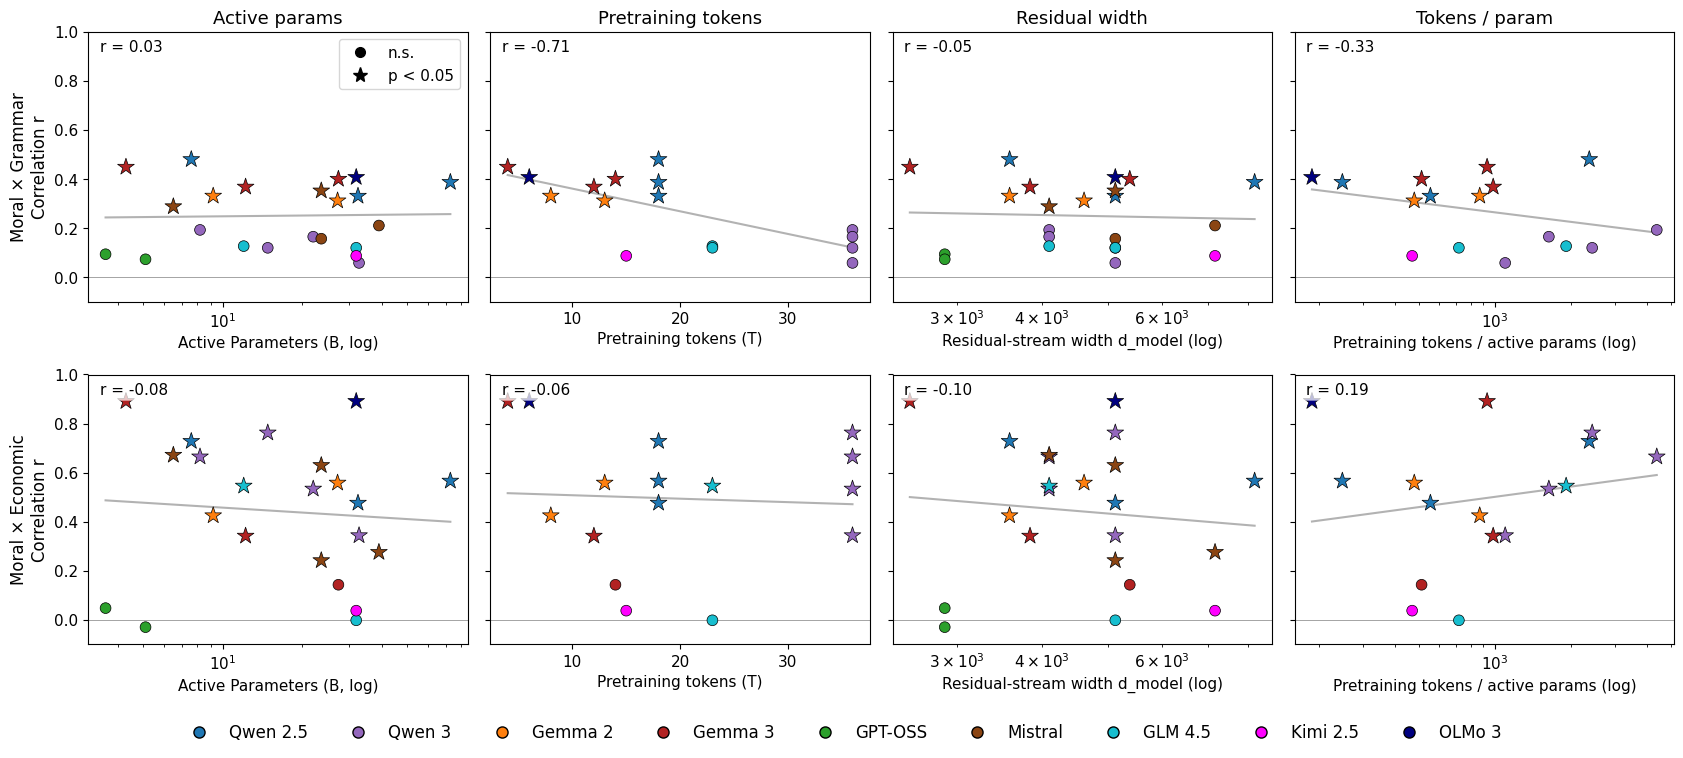


Figure S4 — scaling correlations (Pearson r, p, n):
  Moral × Grammar    | Active Parameters (B, log)                              | r = +0.027, p = 0.9044, n = 22
  Moral × Grammar    | Pretraining tokens (T)                                  | r = -0.713, p = 0.001932, n = 16
  Moral × Grammar    | Residual-stream width d_model (log)                     | r = -0.050, p = 0.8257, n = 22
  Moral × Grammar    | Pretraining tokens / active params (log)                | r = -0.334, p = 0.2054, n = 16
  Moral × Economic   | Active Parameters (B, log)                              | r = -0.084, p = 0.7112, n = 22
  Moral × Economic   | Pretraining tokens (T)                                  | r = -0.057, p = 0.834, n = 16
  Moral × Economic   | Residual-stream width d_model (log)                     | r = -0.104, p = 0.6447, n = 22
  Moral × Economic   | Pretraining tokens / active params (log)                | r = +0.189, p = 0.484, n = 16


In [8]:
# ── Correlation vs model size and training tokens ──
MODEL_SPECS = {
    'qwen-2.5-7b-instruct':            (   7.6,   7.6, 18.0, 3584),
    'qwen-2.5-32b-instruct':           (  32.5,  32.5, 18.0, 5120),
    'qwen-2.5-72b-instruct':           (  72.7,  72.7, 18.0, 8192),

    'qwen3-8b':                        (   8.2,   8.2, 36.0, 4096),
    'qwen3-14b':                       (  14.8,  14.8, 36.0, 5120),
    'qwen3-32b':                       (  32.8,  32.8, 36.0, 5120),
    'qwen3-235b-a22b':                 ( 235.0,  22.0, 36.0, 4096),

    'gemma-2-9b-it':                   (   9.2,   9.2,  8.0, 3584),
    'gemma-2-27b-it':                  (  27.2,  27.2, 13.0, 4608),

    'gemma-3-4b-it':                   (   4.3,   4.3,  4.0, 2560),
    'gemma-3-12b-it':                  (  12.2,  12.2, 12.0, 3840),
    'gemma-3-27b-it':                  (  27.4,  27.4, 14.0, 5376),

    'gpt-oss-20b':                     (  20.9,   3.6, None, 2880),
    'gpt-oss-120b':                    ( 116.8,   5.1, None, 2880),

    'mistral-small-24b-instruct-2501': (  23.6,  23.6, None, 5120),
    'mistral-small-3.2-24b-instruct':  (  23.6,  23.6, None, 5120),
    'mistral-small-2603':              ( 119.0,   6.5, None, 4096),

    'mistral-medium-3.1':              (None, None, None, None),  # closed-source

    'mistral-large-2512':              ( 675.0,  39.0, None, 7168),

    'glm-4.5-air':                     ( 106.0,  12.0, 23.0, 4096),
    'glm-4.5':                         ( 355.0,  32.0, 23.0, 5120),

    'kimi-k2.5':                       (1000.0,  32.0, 15.0, 7168),

    'olmo-3-7b-instruct':              (   7.3,   7.3,  6.0, 4096),
    'olmo-3.1-32b-instruct':           (  32.0,  32.0,  6.0, 5120),

    'gemini-2.5-flash-lite':           (None, None, None, None),  # closed-source
    'gemini-2.5-flash':                (None, None, None, None),  # closed-source
    'gemini-2.5-pro':                  (None, None, None, None),  # closed-source

    'gpt-5.4-nano':                    (None, None, None, None),  # closed-source
    'gpt-5.4-mini':                    (None, None, None, None),  # closed-source
    'gpt-5.4':                         (None, None, None, None),  # closed-source

    'claude-sonnet-4.6':               (None, None, None, None),  # closed-source
    'claude-opus-4.6':                 (None, None, None, None),  # closed-source
}

PARAM_AXIS = 'active_b'  # or 'total_b'

specs_df = pd.DataFrame(
    [{'model': mn, 'total_b': t, 'active_b': a, 'tokens_t': k, 'd_model': d}
     for mn, (t, a, k, d) in MODEL_SPECS.items()]
)
scaled_df = corr_df.merge(specs_df, on='model', how='left')
scaled_df['tokens_per_param'] = scaled_df['tokens_t'] * 1000.0 / scaled_df[PARAM_AXIS]
scaled_df['family_color']    = scaled_df['model'].apply(_family_color)
scaled_df['display_name']    = scaled_df['model'].apply(_short_name)


# ── Combined 2 × 4 grid ──

x_specs = [
    (PARAM_AXIS,
     f'{"Active" if PARAM_AXIS == "active_b" else "Total"} Parameters (B, log)',
     True),
    ('tokens_t',
     'Pretraining tokens (T)',
     False),
    ('d_model',
     'Residual-stream width d_model (log)',
     True),
    ('tokens_per_param',
     f'Pretraining tokens / {("active" if PARAM_AXIS == "active_b" else "total")} params (log)',
     True),
]
y_specs = [
    ('r_grammar',  'p_grammar',  'Moral × Grammar'),
    ('r_economic', 'p_economic', 'Moral × Economic'),
]

fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharey=True)
plt.rcParams.update({'font.size': 12})

scaling_stats = []

for row, (r_col, p_col, row_title) in enumerate(y_specs):
    for col, (x_col, x_label, x_log) in enumerate(x_specs):
        ax = axes[row, col]
        sub = scaled_df.dropna(subset=[x_col, r_col]).copy()
        sig = sub[p_col] < ALPHA

        r_corr, p_corr = np.nan, np.nan
        if len(sub) >= 2:
            x_data = sub[x_col].values.astype(float)
            y_data = sub[r_col].values.astype(float)
            x_for_fit = np.log10(x_data) if x_log else x_data
            slope, intercept = np.polyfit(x_for_fit, y_data, 1)
            x_line = np.linspace(x_data.min(), x_data.max(), 100)
            x_for_eval = np.log10(x_line) if x_log else x_line
            y_line = intercept + slope * x_for_eval
            ax.plot(x_line, y_line, color='gray', linestyle='-',
                    linewidth=1.5, alpha=0.6, zorder=2)
            r_corr, p_corr = sp_stats.pearsonr(x_for_fit, y_data)

        scaling_stats.append((row_title, x_label, r_corr, p_corr, len(sub)))

        ax.scatter(sub.loc[~sig, x_col], sub.loc[~sig, r_col],
                   s=60, c=sub.loc[~sig, 'family_color'],
                   edgecolors='black', linewidths=0.5, marker='o', zorder=3)
        ax.scatter(sub.loc[sig, x_col], sub.loc[sig, r_col],
                   s=160, c=sub.loc[sig, 'family_color'],
                   edgecolors='black', linewidths=0.5, marker='*', zorder=3)
        # for _, r in sub.iterrows():
            # ax.annotate(r['display_name'], (r[x_col], r[r_col]),
                        # fontsize=8, xytext=(3, 2), textcoords='offset points')

        ax.axhline(0, color='gray', linewidth=0.5)
        if x_log:
            ax.set_xscale('log')
        ax.set_xlabel(x_label, fontsize=11)
        # ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.1, 1)

        if not (np.isnan(r_corr) or np.isnan(p_corr)):
            ax.text(0.03, 0.97,
                    f'r = {r_corr:.2f}',
                    transform=ax.transAxes, fontsize=11,
                    va='top', ha='left',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white', edgecolor='none', alpha=0.75))

        if row == 0:
            col_titles = ['Active params', 'Pretraining tokens',
                          'Residual width', 'Tokens / param']
            ax.set_title(col_titles[col], fontsize=13)
        if col == 0:
            ax.set_ylabel(f'{row_title}\nCorrelation r', fontsize=12)

shape_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=7, label='n.s.'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='black',
           markeredgecolor='black', markersize=11, label=f'p < {ALPHA}'),
]
axes[0, 0].legend(handles=shape_handles, loc='upper right', fontsize=11,
                  frameon=True)

models_present = sorted({
    m
    for x_col, _, _ in x_specs
    for m in scaled_df.dropna(subset=[x_col])['model'].tolist()
})
_n_families = len([f for f in MODEL_FAMILY_COLORS
                   if f in {_family_of(m) for m in models_present}])
_family_legend(fig, models_present,
               loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=_n_families, frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/cross_model_corr_combined_2x4.eps',
            format='eps', bbox_inches='tight')
plt.show()

# ── Per-panel scaling correlations (Pearson r, p, n) ──
print('\nFigure S4 — scaling correlations (Pearson r, p, n):')
for row_title, x_label, r_corr, p_corr, n in scaling_stats:
    if np.isnan(r_corr):
        print(f'  {row_title:18s} | {x_label:55s} | (insufficient data, n={n})')
    else:
        print(f'  {row_title:18s} | {x_label:55s} | '
              f'r = {r_corr:+.3f}, p = {p_corr:.4g}, n = {n}')

## Table 2 — Model × human / log-price correlations

In [9]:
# ── Table 2 — per-model correlations (LaTeX, dual-column layout) ──
GRAMMAR_RATE_COLS  = ['item', 'morality_mean', 'grammar_mean']
ECONOMIC_RATE_COLS = ['item', 'morality_mean', 'economic_mean']

EOL   = r' \\'
ADDLS = r'\addlinespace'

def _r(x, y):
    if len(x) < 2 or len(y) < 2:
        return np.nan
    m = ~(np.isnan(x) | np.isnan(y))
    if m.sum() < 2:
        return np.nan
    return np.corrcoef(x[m], y[m])[0, 1]

def _fmt(r):
    return '-' if (r is None or (isinstance(r, float) and np.isnan(r))) else f'{r:.2f}'

# ── Static rows from the original table (no cached data for these). ──
NA = np.nan
STATIC_ROWS = {
    'GPT-3.5':        [[0.97,  0.06,  0.00], [0.56,  0.70, NA], [0.46, NA,  0.31]],
    'GPT-4o mini':    [[0.98,  0.04, -0.03], [0.12,  0.96, NA], [0.00, NA,  0.48]],
    'Gemini 2.0':     [[0.98,  0.05,  0.01], [0.07,  0.93, NA], [-0.04, NA, 0.41]],
    'GPT-emb-3':      [[0.82, -0.01, -0.17], [0.68,  0.14, NA], [-0.19, NA, 0.27]],
    'Gemini-emb-001': [[0.53,  0.33, -0.24], [0.59, -0.09, NA], [0.62, NA, -0.13]],
}

# ── Compute rows from cached ratings. ──
econ_meta = economic_items[['item', 'price']].copy()
econ_meta['log_price'] = np.log10(econ_meta['price'].astype(float))
hum = human_ratings[['item', 'morality_rating', 'syntax_rating']]

computed = {}
for mp in MODEL_PATHS:
    mn = mp.split('/')[-1]
    gpath = f'./data/{mn}/moralgrammar68_ratings.csv'
    epath = f'./data/{mn}/moraleconomic68_ratings.csv'
    if not (os.path.exists(gpath) and os.path.exists(epath)):
        continue

    g = pd.read_csv(gpath)[GRAMMAR_RATE_COLS].rename(
        columns={'morality_mean': 'm_moral', 'grammar_mean': 'm_gram'})
    e = pd.read_csv(epath)[ECONOMIC_RATE_COLS].rename(
        columns={'morality_mean': 'm_moral_me', 'economic_mean': 'm_econ'})

    gm = g.merge(hum, on='item', how='inner').dropna(
        subset=['m_moral', 'm_gram', 'morality_rating', 'syntax_rating'])
    em = e.merge(econ_meta, on='item', how='inner').dropna(
        subset=['m_moral_me', 'm_econ', 'log_price'])

    moral_row = [
        _r(gm['m_moral'].values,    gm['morality_rating'].values),
        _r(gm['m_moral'].values,    gm['syntax_rating'].values),
        _r(em['m_moral_me'].values, em['log_price'].values),
    ]
    gram_row = [
        _r(gm['m_gram'].values, gm['morality_rating'].values),
        _r(gm['m_gram'].values, gm['syntax_rating'].values),
        NA,
    ]
    econ_row = [
        _r(em['m_econ'].values, em['m_moral_me'].values),
        NA,
        _r(em['m_econ'].values, em['log_price'].values),
    ]
    computed[_short_name(mn)] = [moral_row, gram_row, econ_row]

# ── Final display order: closed-source → open-weight families → embeddings.
ORDER = [
    # Closed-source / proprietary chat (static, no cached data)
    'GPT-3.5',
    'GPT-4o mini',
    'Gemini 2.0',
    # Qwen 2.5 / 3
    'Qwen 2.5 7B', 'Qwen 2.5 32B', 'Qwen 2.5 72B',
    'Qwen3 8B', 'Qwen3 14B', 'Qwen3 32B', 'Qwen3 235B-A22B',
    # Gemma 2 / 3
    'Gemma 2 9B', 'Gemma 2 27B',
    'Gemma 3 4B', 'Gemma 3 12B', 'Gemma 3 27B',
    # GPT-OSS
    'GPT-OSS 20B', 'GPT-OSS 120B',
    # Mistral
    'Mistral Small 24B', 'Mistral Small 3.2 24B', 'Mistral Small 4',
    'Mistral Medium 3.1', 'Mistral Large 3',
    # GLM, Kimi, OLMo
    'GLM-4.5 Air', 'GLM-4.5',
    'Kimi K2.5',
    'OLMo 3.1 32B',
    # Closed-source chat (cached data — listed under their families)
    'Gemini 2.5 Flash Lite', 'Gemini 2.5 Flash', 'Gemini 2.5 Pro',
    'GPT-5.4 Nano', 'GPT-5.4 Mini', 'GPT-5.4',
    'Claude Sonnet 4.6', 'Claude Opus 4.6',
    # Embeddings
    'GPT-emb-3', 'Gemini-emb-001',
]

ordered_rows = []
for name in ORDER:
    if name in STATIC_ROWS:
        ordered_rows.append((name, STATIC_ROWS[name]))
    elif name in computed:
        ordered_rows.append((name, computed[name]))

# ── Format LaTeX body ──
SEP = ' & & '   # spacer cell between the two halves (renders as col 5)

def _emit_block(rows_block):
    lines = []
    for i, (name, dims) in enumerate(rows_block):
        if i > 0:
            lines.append(ADDLS)
        m, g, e = dims
        lines.append(f'{name} - Moral & {_fmt(m[0])} & {_fmt(m[1])} & {_fmt(m[2])}{EOL}')
        lines.append(f'{name} - Gram  & {_fmt(g[0])} & {_fmt(g[1])} & {_fmt(g[2])}{EOL}')
        lines.append(f'{name} - Econ  & {_fmt(e[0])} & {_fmt(e[1])} & {_fmt(e[2])}{EOL}')
    return lines

half = (len(ordered_rows) + 1) // 2
left, right = ordered_rows[:half], ordered_rows[half:]
left_lines  = _emit_block(left)
right_lines = _emit_block(right)

EMPTY_4CELL = ' & & & '   # 4 empty cells: name | Moral | Gram | Econ
pad = max(len(left_lines), len(right_lines))
left_lines  += [EMPTY_4CELL] * (pad - len(left_lines))
right_lines += [EMPTY_4CELL] * (pad - len(right_lines))

def _strip_eol(s):
    return s[:-len(EOL)] if s.endswith(EOL) else s

body = []
for L, R in zip(left_lines, right_lines):
    L_is_gap = L.strip() == ADDLS
    R_is_gap = R.strip() == ADDLS
    if L_is_gap and R_is_gap:
        body.append(ADDLS)
    elif L_is_gap:
        body.append(ADDLS)
        body.append(EMPTY_4CELL + SEP + _strip_eol(R) + EOL)
    elif R_is_gap:
        body.append(ADDLS)
        body.append(_strip_eol(L) + SEP + EMPTY_4CELL + EOL)
    else:
        body.append(_strip_eol(L) + SEP + _strip_eol(R) + EOL)

latex = r"""{\footnotesize
\setlength{\tabcolsep}{3pt}
\setlength{\LTleft}{0pt}
\setlength{\LTright}{0pt}
\begin{longtable}{@{\extracolsep{\fill}}lccc c lccc@{}}
\toprule
& \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) & & & \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) \\
\cmidrule(lr){2-3} \cmidrule(lr){4-4} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
Model - Dim & Moral & Gram & Econ & & Model - Dim & Moral & Gram & Econ \\
\midrule
\endfirsthead
\toprule
& \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) & & & \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) \\
\cmidrule(lr){2-3} \cmidrule(lr){4-4} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
Model - Dim & Moral & Gram & Econ & & Model - Dim & Moral & Gram & Econ \\
\midrule
\endhead
\midrule
\multicolumn{9}{r}{\textit{continued on next page}} \\
\endfoot
\bottomrule
\endlastfoot
""" + '\n'.join(body) + r"""
\end{longtable}
}"""

print(latex)

{\footnotesize
\setlength{\tabcolsep}{3pt}
\setlength{\LTleft}{0pt}
\setlength{\LTright}{0pt}
\begin{longtable}{@{\extracolsep{\fill}}lccc c lccc@{}}
\toprule
& \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) & & & \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) \\
\cmidrule(lr){2-3} \cmidrule(lr){4-4} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
Model - Dim & Moral & Gram & Econ & & Model - Dim & Moral & Gram & Econ \\
\midrule
\endfirsthead
\toprule
& \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) & & & \multicolumn{2}{c}{Humans} & $\log_{10}$(US\$) \\
\cmidrule(lr){2-3} \cmidrule(lr){4-4} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
Model - Dim & Moral & Gram & Econ & & Model - Dim & Moral & Gram & Econ \\
\midrule
\endhead
\midrule
\multicolumn{9}{r}{\textit{continued on next page}} \\
\endfoot
\bottomrule
\endlastfoot
GPT-3.5 - Moral & 0.97 & 0.06 & 0.00 & & Mistral Small 3.2 24B - Moral & 0.98 & 0.05 & -0.02 \\
GPT-3.5 - Gram  & 0.56 & 0.70 & - & & Mistral Small 3.2 24B - Gram  & 0.34 & 0.86 & -

## MoralGrammar68 / MoralEconomic68 rating ANOVAs

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

def _fmt_anova_cell(F, p, df_num, df_den):
    if F is None or (isinstance(F, float) and np.isnan(F)):
        return '-'
    return f'F({int(df_num)},{int(df_den)}) = {F:.3f}, p<{p:.3f}'

def _run_anova_full(df, dv, factor_a, factor_b):
    formula = f'{dv} ~ C({factor_a}) + C({factor_b}) + C({factor_a}):C({factor_b})'
    try:
        mdl = ols(formula, data=df).fit()
        tbl = sm.stats.anova_lm(mdl, type=2)
    except Exception:
        return [(np.nan, np.nan, np.nan, np.nan)] * 3
    df_den = tbl.loc['Residual', 'df']
    out = []
    for key in (f'C({factor_a})', f'C({factor_b})', f'C({factor_a}):C({factor_b})'):
        out.append((tbl.loc[key, 'F'], tbl.loc[key, 'PR(>F)'],
                    tbl.loc[key, 'df'], df_den))
    return out

ANOVA_SPECS = [
    ('Morality (MG68)', 'mg', 'morality_mean', 'syntax_level'),
    ('Grammar (MG68)',  'mg', 'grammar_mean',  'syntax_level'),
    ('Morality (ME68)', 'me', 'morality_mean', 'economic_level'),
    ('Economic (ME68)', 'me', 'economic_mean', 'economic_level'),
]

GRAMMAR_KEEP_COLS  = ['item', 'morality_mean', 'grammar_mean']
ECONOMIC_KEEP_COLS = ['item', 'morality_mean', 'economic_mean']

def _load_keep(path, cols):
    return pd.read_csv(path)[cols]

model_anovas = {}
for mp in MODEL_PATHS:
    mn = mp.split('/')[-1]
    gpath = f'./data/{mn}/moralgrammar68_ratings.csv'
    epath = f'./data/{mn}/moraleconomic68_ratings.csv'
    if not (os.path.exists(gpath) and os.path.exists(epath)):
        continue

    g_df = (grammar_items.merge(_load_keep(gpath, GRAMMAR_KEEP_COLS), on='item', how='left')
                          .dropna(subset=['morality_mean', 'grammar_mean'])
                          .reset_index(drop=True))
    e_df = (economic_items.merge(_load_keep(epath, ECONOMIC_KEEP_COLS), on='item', how='left')
                           .dropna(subset=['morality_mean', 'economic_mean'])
                           .reset_index(drop=True))

    rows = []
    for label, ds, dv, sec in ANOVA_SPECS:
        df = g_df if ds == 'mg' else e_df
        rows.append((label, _run_anova_full(df, dv, 'morality_level', sec)))
    model_anovas[_short_name(mn)] = rows

ORDER_T3 = [n for n in [
    'Qwen 2.5 7B', 'Qwen 2.5 32B', 'Qwen 2.5 72B',
    'Qwen3 8B', 'Qwen3 14B', 'Qwen3 32B', 'Qwen3 235B-A22B',
    'Gemma 2 9B', 'Gemma 2 27B',
    'Gemma 3 4B', 'Gemma 3 12B', 'Gemma 3 27B',
    'GPT-OSS 20B', 'GPT-OSS 120B',
    'Mistral Small 24B', 'Mistral Small 3.2 24B', 'Mistral Small 4',
    'Mistral Medium 3.1', 'Mistral Large 3',
    'GLM-4.5 Air', 'GLM-4.5',
    'Kimi K2.5',
    'OLMo 3.1 32B',
    'Gemini 2.5 Flash Lite', 'Gemini 2.5 Flash', 'Gemini 2.5 Pro',
    'GPT-5.4 Nano', 'GPT-5.4 Mini', 'GPT-5.4',
    'Claude Sonnet 4.6', 'Claude Opus 4.6',
] if n in model_anovas]

# ── LaTeX ──
HDR = 'DV (set) & Moral level effect & Secondary level effect & Interaction'
EOL = r' \\'

LATEX_HEADER = r"""\subsection{MoralGrammar68 / MoralEconomic68 rating ANOVAs}
\label{sec:behavioral-anovas}

Per-model 2-way type-II ANOVAs on each rating dimension. The MG68 ANOVAs use
\texttt{morality\_level} $\times$ \texttt{syntax\_level} as factors; the ME68 ANOVAs
use \texttt{morality\_level} $\times$ \texttt{economic\_level}. Each row reports the
F-statistic and p-value for the morality-level main effect, the secondary-level main
effect, and their interaction.
"""

def _emit_one_model(name):
    rows = model_anovas[name]
    body_lines = []
    for label, effects in rows:
        cells = [_fmt_anova_cell(F, p, dn, dd) for (F, p, dn, dd) in effects]
        body_lines.append(f'{label} & {cells[0]} & {cells[1]} & {cells[2]}{EOL}')

    parts = [
        f'\\subsubsection{{{name}}}',
        r'\noindent\resizebox{\textwidth}{!}{%',
        r'\begin{tabular}{lccc}',
        r'\toprule',
        f'{HDR}{EOL}',
        r'\midrule',
        *body_lines,
        r'\bottomrule',
        r'\end{tabular}%',
        r'}',
    ]
    return '\n'.join(parts)

print(LATEX_HEADER)
for name in ORDER_T3:
    print()
    print(_emit_one_model(name))

\subsection{MoralGrammar68 / MoralEconomic68 rating ANOVAs}
\label{sec:behavioral-anovas}

Per-model 2-way type-II ANOVAs on each rating dimension. The MG68 ANOVAs use
\texttt{morality\_level} $\times$ \texttt{syntax\_level} as factors; the ME68 ANOVAs
use \texttt{morality\_level} $\times$ \texttt{economic\_level}. Each row reports the
F-statistic and p-value for the morality-level main effect, the secondary-level main
effect, and their interaction.


\subsubsection{Qwen 2.5 7B}
\noindent\resizebox{\textwidth}{!}{%
\begin{tabular}{lccc}
\toprule
DV (set) & Moral level effect & Secondary level effect & Interaction \\
\midrule
Morality (MG68) & F(2,56) = 470.304, p<0.000 & F(3,56) = 0.295, p<0.829 & F(6,56) = 0.037, p<1.000 \\
Grammar (MG68) & F(2,56) = 26.002, p<0.000 & F(3,56) = 43.499, p<0.000 & F(6,56) = 5.001, p<0.000 \\
Morality (ME68) & F(2,56) = 745.928, p<0.000 & F(3,56) = 0.040, p<0.989 & F(6,56) = 0.017, p<1.000 \\
Economic (ME68) & F(2,56) = 31.905, p<0.000 & F(3,56) = 2.586,